In [6]:
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils, stats_utils
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.lfs import EuLfs

# load paths
useful_paths = utils.UsefulPaths()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
config_file = "eu_lfs_config.yml"
config = utils.load_config(os.path.join(useful_paths.config_dir, config_file))

In [8]:
eulfs = EuLfs(config=config)

In [9]:
fpath_fr = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\FR_YEAR_1998_onwards\FR2019_y.csv"
fpath_de = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\DE_YEAR_1998_onwards\DE2019_y.csv"
fpath_pl = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\PL_YEAR_1998_onwards\PL2019_y.csv"
fpath_bg = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\BG_YEAR_1998_onwards\BG2019_y.csv"

In [10]:
cntry = "MT"
fpath = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles" \
        r"\{}_YEAR_1998_onwards\{}2019_y.csv".format(cntry, cntry)

df = pd.read_csv(fpath, usecols=eulfs.variables, na_values=eulfs.na_values,
                 dtype=eulfs.dtypes_in)
df[df.COUNTRYW == '000-OWN COUNTRY']
df

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,DEGURBA,HHTYPE,COEFF,AGE,ILOSTAT,EDUC4WN,HATLEV1D,MAINSTAT,INCDECIL
0,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01375,77,3,0,M,4,NaN
1,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01100,77,3,0,M,4,NaN
2,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01600,47,3,0,L,7,NaN
3,1,1,H,800,000-OWN COUNTRY,NaN,1,2019,MT,NaN,1,1,0.01225,52,1,0,L,1,08
4,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01725,22,2,1,L,8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20971,1,1,K,100,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.02250,57,1,0,M,1,10
20972,2,1,K,300,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.01875,52,1,0,M,1,08
20973,1,1,C,200,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.03250,27,1,0,H,1,08
20974,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,2,1,0.04875,37,2,1,L,2,NaN


In [12]:
df_all = eulfs.read_merged_file(year=2019)

In [13]:
df_all

,AGE,COEFF,COEFF_share_brown_esco_mean,COEFF_share_green_esco_mean,COEFF_share_green_gtp_mean,COEFF_share_neutral_esco_mean,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,...,isco_label_4,isco_level_1,isco_level_2,isco_level_3,isco_level_4,n_occ_esco_sum,share_brown_esco_mean,share_green_esco_mean,share_green_gtp_mean,share_neutral_esco_mean
0,52,82.5525,0.998881,2.768554,21.297373,78.785065,AT,AT,3,0,...,NaN,NaN,NaN,132,NaN,118.0,0.012100,0.033537,0.257986,0.954363
1,17,82.5525,1.117643,7.181130,32.827993,74.253727,AT,AT,3,1,...,NaN,NaN,NaN,311,NaN,134.0,0.013539,0.086989,0.397662,0.899473
2,42,47.2325,0.000000,0.000000,0.000000,47.232500,AT,AT,3,0,...,NaN,NaN,NaN,411,NaN,2.0,0.000000,0.000000,0.000000,1.000000
3,47,52.9450,0.518645,2.668451,0.000000,49.757904,AT,AT,3,0,...,NaN,NaN,NaN,911,NaN,7.0,0.009796,0.050400,0.000000,0.939804
4,47,75.8625,0.000000,0.225781,0.000000,75.636719,AT,AT,2,0,...,NaN,NaN,NaN,011,NaN,12.0,0.000000,0.002976,0.000000,0.997024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546564,17,1100.1400,0.000000,2.014908,0.000000,1098.125092,UK,UK,1,1,...,NaN,NaN,NaN,421,NaN,14.0,0.000000,0.001832,0.000000,0.998168
1546565,52,1790.6100,81.733828,175.305163,873.219677,1533.571009,UK,UK,3,0,...,NaN,NaN,NaN,211,NaN,29.0,0.045646,0.097902,0.487666,0.856452
1546566,57,1858.6800,40.006625,118.057101,419.701935,1700.616274,UK,UK,2,0,...,NaN,NaN,NaN,833,NaN,11.0,0.021524,0.063517,0.225806,0.914959
1546567,57,1723.3000,0.000000,4.008418,0.000000,1719.291582,UK,UK,2,0,...,NaN,NaN,NaN,263,NaN,66.0,0.000000,0.002326,0.000000,0.997674


In [14]:
col = "isco_label_2"
df_all.dropna(subset=[col])

,AGE,COEFF,COEFF_share_brown_esco_mean,COEFF_share_green_esco_mean,COEFF_share_green_gtp_mean,COEFF_share_neutral_esco_mean,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,...,isco_label_4,isco_level_1,isco_level_2,isco_level_3,isco_level_4,n_occ_esco_sum,share_brown_esco_mean,share_green_esco_mean,share_green_gtp_mean,share_neutral_esco_mean
105810,42,178.4800,0.123944,6.717179,20.997647,171.638876,BG,BG,1,0,...,NaN,NaN,14,NaN,NaN,72.0,0.000694,0.037635,0.117647,0.961670
105811,42,190.7300,0.075408,0.786583,22.438824,189.868009,BG,BG,1,0,...,NaN,NaN,52,NaN,NaN,74.0,0.000395,0.004124,0.117647,0.995481
105812,42,190.7300,0.000000,4.250459,44.784187,186.479541,BG,BG,1,0,...,NaN,NaN,24,NaN,NaN,130.0,0.000000,0.022285,0.234804,0.977715
105813,37,210.6500,4.584653,18.429705,76.259605,187.635642,BG,BG,1,0,...,NaN,NaN,31,NaN,NaN,267.0,0.021764,0.087490,0.362020,0.890746
105814,37,226.2700,1.761546,7.456931,73.501237,217.051523,BG,BG,1,0,...,NaN,NaN,13,NaN,NaN,184.0,0.007785,0.032956,0.324839,0.959259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243074,62,145.6950,3.635147,5.544323,32.898871,136.515529,PL,PL,3,0,...,NaN,NaN,83,NaN,NaN,51.0,0.024950,0.038054,0.225806,0.936995
1243075,37,212.4975,8.266981,5.230058,28.333000,199.000462,PL,PL,3,0,...,NaN,NaN,82,NaN,NaN,36.0,0.038904,0.024612,0.133333,0.936484
1243076,47,321.7000,31.380099,12.502759,16.863337,277.817142,PL,PL,3,0,...,NaN,NaN,81,NaN,NaN,260.0,0.097545,0.038865,0.052419,0.863591
1243077,42,213.4000,3.862762,8.419019,13.125794,201.118219,PL,PL,3,0,...,NaN,NaN,75,NaN,NaN,116.0,0.018101,0.039452,0.061508,0.942447


In [15]:
def perc_missing(df):
    return df.isna().sum() / df.shape[0]

perc_missing(df_all)

AGE                              0.000000
COEFF                            0.001900
COEFF_share_brown_esco_mean      0.010458
COEFF_share_green_esco_mean      0.010458
COEFF_share_green_gtp_mean       0.010458
COEFF_share_neutral_esco_mean    0.010458
COUNTRY                          0.000000
COUNTRYW                         0.000000
DEGURBA                          0.000000
EDUC4WN                          0.001514
FTPT                             0.000077
HATLEV1D                         0.002325
HHTYPE                           0.000000
ILOSTAT                          0.000000
INCDECIL                         0.383396
ISCO                             0.000000
ISCO3D                           0.000000
MAINSTAT                         0.027033
NACE1D                           0.003823
NACE1D_label                     0.003823
NUTS_ID                          0.040469
REFYEAR                          0.000000
REGION                           0.066406
REGIONW                          0

In [16]:
countries = ["NL"]
perc_missing(df_all.loc[df_all["COUNTRY"].isin(countries)])

AGE                              0.000000
COEFF                            0.000000
COEFF_share_brown_esco_mean      0.015414
COEFF_share_green_esco_mean      0.015414
COEFF_share_green_gtp_mean       0.015414
COEFF_share_neutral_esco_mean    0.015414
COUNTRY                          0.000000
COUNTRYW                         0.000000
DEGURBA                          0.000000
EDUC4WN                          0.000000
FTPT                             0.000000
HATLEV1D                         0.008874
HHTYPE                           0.000000
ILOSTAT                          0.000000
INCDECIL                         0.167079
ISCO                             0.000000
ISCO3D                           0.000000
MAINSTAT                         0.000485
NACE1D                           0.090380
NACE1D_label                     0.090380
NUTS_ID                          0.000000
REFYEAR                          0.000000
REGION                           1.000000
REGIONW                          1

In [17]:
ix_isco = df_all.loc[:, "ISCO3D"].sort_values().index.values
df_all.iloc[ix_isco]

,AGE,COEFF,COEFF_share_brown_esco_mean,COEFF_share_green_esco_mean,COEFF_share_green_gtp_mean,COEFF_share_neutral_esco_mean,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,...,isco_label_4,isco_level_1,isco_level_2,isco_level_3,isco_level_4,n_occ_esco_sum,share_brown_esco_mean,share_green_esco_mean,share_green_gtp_mean,share_neutral_esco_mean
1478168,37,75.9650,NaN,NaN,NaN,NaN,SK,SK,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1171912,42,139.7800,NaN,NaN,NaN,NaN,PL,PL,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1084604,37,18.5000,0.030378,0.051484,0.0,18.418138,MT,MT,1,0,...,NaN,0,NaN,NaN,NaN,21.0,0.001642,0.002783,0.0,0.995575
1084599,27,42.5000,0.069787,0.118275,0.0,42.311939,MT,MT,2,0,...,NaN,0,NaN,NaN,NaN,21.0,0.001642,0.002783,0.0,0.995575
1483567,27,95.3000,NaN,NaN,NaN,NaN,SK,SK,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890975,57,65.5250,0.420032,1.742524,0.0,63.362444,IT,IT,1,1,...,NaN,NaN,NaN,962,NaN,12.0,0.006410,0.026593,0.0,0.966996
890985,57,91.4750,0.586378,2.432620,0.0,88.456002,IT,IT,1,0,...,NaN,NaN,NaN,962,NaN,12.0,0.006410,0.026593,0.0,0.966996
1244683,57,89.2475,0.572099,2.373383,0.0,86.302017,PT,PT,2,0,...,NaN,NaN,NaN,962,NaN,12.0,0.006410,0.026593,0.0,0.966996
889573,32,36.4750,0.233814,0.969990,0.0,35.271196,IT,IT,2,0,...,NaN,NaN,NaN,962,NaN,12.0,0.006410,0.026593,0.0,0.966996


In [18]:
cols = ["COEFF_share_green_esco_mean", "COEFF_share_brown_esco_mean",
        "COEFF_share_neutral_esco_mean"]

np.allclose(df_all.loc[:, cols].sum(axis=1), df_all.COEFF)
error = np.abs(df_all.loc[:, cols].sum(axis=1) - df_all.COEFF)

df_all.iloc[error.sort_values(ascending=False).index.values]

,AGE,COEFF,COEFF_share_brown_esco_mean,COEFF_share_green_esco_mean,COEFF_share_green_gtp_mean,COEFF_share_neutral_esco_mean,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,...,isco_label_4,isco_level_1,isco_level_2,isco_level_3,isco_level_4,n_occ_esco_sum,share_brown_esco_mean,share_green_esco_mean,share_green_gtp_mean,share_neutral_esco_mean
529228,32,3491.01,NaN,NaN,NaN,NaN,ES,ES,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
596096,57,2136.53,NaN,NaN,NaN,NaN,FR,FR,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539025,37,2049.67,NaN,NaN,NaN,NaN,ES,ES,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
535198,27,1987.54,NaN,NaN,NaN,NaN,ES,ES,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
548848,52,1981.63,NaN,NaN,NaN,NaN,ES,ES,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565090,57,NaN,NaN,NaN,NaN,NaN,ES,ES,1,0,...,NaN,NaN,NaN,522,NaN,47.0,0.000622,0.004529,0.117647,0.994848
565091,42,NaN,NaN,NaN,NaN,NaN,ES,ES,3,1,...,NaN,NaN,NaN,332,NaN,57.0,0.003715,0.022971,0.271250,0.973314
565092,22,NaN,NaN,NaN,NaN,NaN,ES,ES,1,0,...,NaN,NaN,NaN,514,NaN,17.0,0.000000,0.006694,0.000000,0.993306
565095,62,NaN,NaN,NaN,NaN,NaN,ES,ES,1,0,...,NaN,NaN,NaN,723,NaN,33.0,0.034067,0.025934,0.297436,0.939999


Group by LFS variables

In [19]:
age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",
                           "COEFF_share_brown_esco_mean",
                      "COEFF_share_neutral_esco_mean"].sum()

coeff_by_age = df_all.groupby("AGE")["COEFF"].sum()

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_5116\3363292881.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",


In [20]:
age_by_gbn_shares_rel = age_by_gbn_shares.copy()
for col in age_by_gbn_shares_rel.columns:
    age_by_gbn_shares_rel[col] = age_by_gbn_shares_rel[col] / coeff_by_age

In [21]:
age_by_gbn_shares_rel

,COEFF_share_green_esco_mean,COEFF_share_brown_esco_mean,COEFF_share_neutral_esco_mean
AGE,,,
17,0.037337,0.013615,0.942234
22,0.035037,0.014639,0.945988
27,0.035428,0.013706,0.945322
32,0.036715,0.013408,0.943254
37,0.037657,0.013409,0.942894
42,0.038629,0.013627,0.941110
47,0.039663,0.013942,0.940128
52,0.040697,0.013707,0.939446
57,0.041830,0.013828,0.938142


<AxesSubplot:xlabel='AGE'>

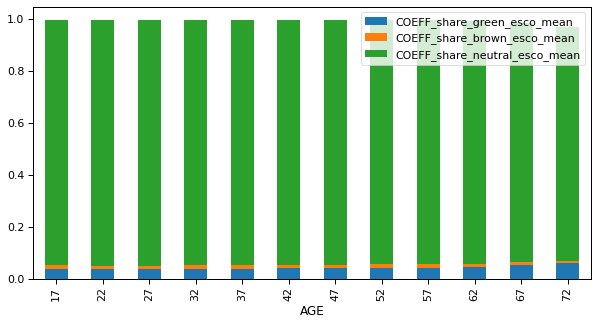

In [22]:
age_by_gbn_shares_rel.plot.bar(stacked=True, figsize=(10, 5))